# Lab 1

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import requests

header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0'} 
url = 'https://charlottesville.craigslist.org/search/cla?purveyor=owner#search=2~gallery~48' 
raw = requests.get(url,headers=header) 

In [30]:
from bs4 import BeautifulSoup as soup 
bsObj = soup(raw.content,'html.parser') 
listings = bsObj.find_all(class_="cl-static-search-result") 

import re
apparel_type = ['backpack', 'sneakers', 'sweater', 'blouse', 'jacket', 'wallet',
'hoodie', 'pants', 'skirt', 'jeans', 'dress', 'boots', 'shirt',
 'coat', 'hat', 'bag']


gender_keywords = {
    'womens': ['womens', "women's", 'women', 'female', 'ladies', 'lady'],  # Check womens FIRST
    'mens': ['mens', "men's", 'men', 'male'],  # Check mens SECOND
    'kids': ['kids', 'children', 'boys', "boy's", 'girls', "girl's", 'toddler', 'youth', 'child']
}

data = []
for k in range(len(listings)):
    title_tag = listings[k].find('div', class_='title')
    price_tag = listings[k].find('div', class_='price')
    link_tag = listings[k].find(href=True)
    
    if title_tag:
        title = title_tag.get_text().strip().lower()
        
        if price_tag:
            price = price_tag.get_text().strip()
        else:
            price = np.nan
        
        if link_tag:
            link = link_tag['href']
        else:
            link = np.nan
        
        apparel = 'missing'
        for ctype in apparel_type:
            if ctype in title:
                apparel = ctype
                break
        
        gender = 'missing'
        for gender_cat, keywords in gender_keywords.items():
            if any(keyword in title for keyword in keywords):
                gender = gender_cat
                break
        
        size_regex = re.search(r'\b(xxl|xl|xs|[0-9]+[a-z]?|[0-9]+-[0-9]+|size\s*[0-9]+)\b', title)
        if size_regex is None:
            size = np.nan
        else:
            size = size_regex.group(0).upper()
        
        data.append({
    'title': title,
    'price': price,
    'apparel': apparel,  
    'gender': gender,
    'size': size,
    'link': link
})

df = pd.DataFrame.from_dict(data)
df['price'] = df['price'].str.replace('$', '')
df['price'] = df['price'].str.replace(',', '')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
print(df.shape)
df.to_csv('./craigslist_cville_clothes.csv', index=False)
df.head(20)


(125, 6)


,title,price,apparel,gender,size,link
0,fila men sneakers 8m,25,sneakers,mens,8M,https://charlottesville.craigslist.org/clo/d/s...
1,2 size 2x long skirts,10,skirt,missing,2,https://charlottesville.craigslist.org/clo/d/c...
2,samsonite backpack,10,backpack,missing,NaN,https://charlottesville.craigslist.org/clo/d/c...
3,betsey johnson wallet,10,wallet,missing,NaN,https://charlottesville.craigslist.org/clo/d/c...
4,main street collection tote/bag,20,bag,missing,NaN,https://charlottesville.craigslist.org/clo/d/t...
5,cross handbag,20,bag,missing,NaN,https://charlottesville.craigslist.org/clo/d/t...
6,women’s size 8 minnetonka fringe boots,30,boots,womens,SIZE 8,https://charlottesville.craigslist.org/clo/d/m...
7,"hand knit royal blue ""fisherman style"" pull-ov...",70,sweater,missing,NaN,https://charlottesville.craigslist.org/clo/d/c...
8,hand-knit wool & silk fair isle sweater,70,sweater,missing,NaN,https://charlottesville.craigslist.org/clo/d/c...
9,beautiful hand-knit fair isle sweater,60,sweater,missing,NaN,https://charlottesville.craigslist.org/clo/d/c...


                mean  median  count
apparel                            
backpack  283.333333    40.0      3
coat      148.500000    55.0     10
boots      96.250000    70.0      8
jacket     93.769231    60.0     13
sweater    66.875000    70.0      8
missing    55.632653    19.0     49
dress      55.000000    30.0      3
hoodie     50.000000    50.0      1
hat        36.333333    40.0      6
pants      25.000000    15.0      5


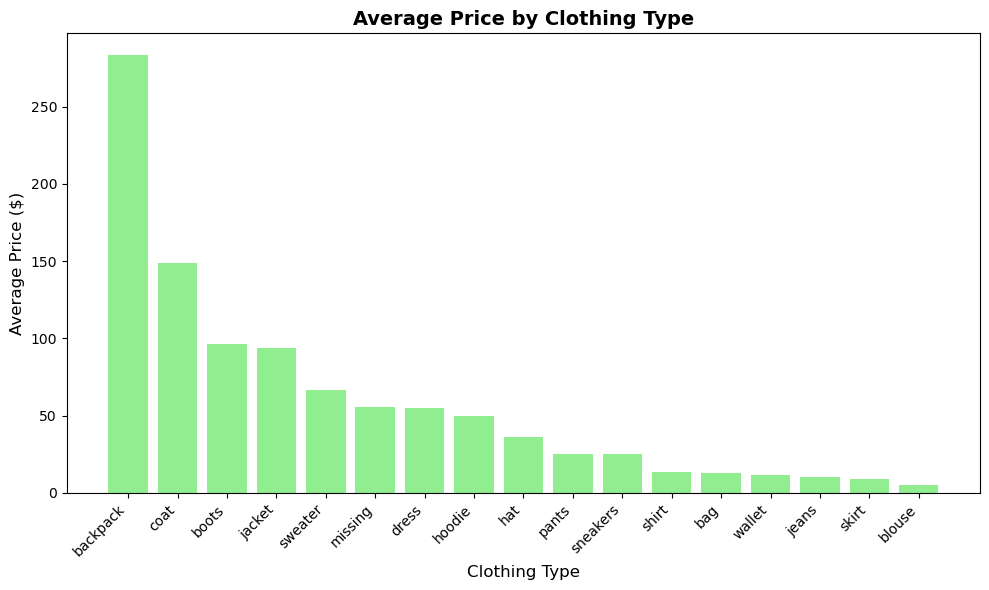

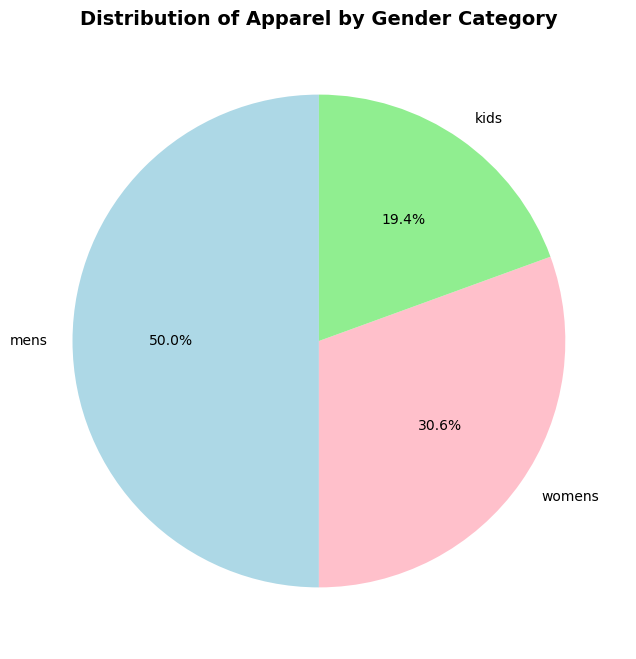

In [29]:

# ANALYSIS

# Price Analysis
price_analysis = df.groupby('apparel')['price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False).head(10)
print(price_analysis)

# Bar Plot of Average Prices Per Item
plt.figure(figsize=(10, 6))
price_by_type = df.groupby('apparel')['price'].mean().sort_values(ascending=False)
plt.bar(range(len(price_by_type)), price_by_type.values, color='lightgreen')
plt.xticks(range(len(price_by_type)), price_by_type.index, rotation=45, ha='right')
plt.xlabel('Clothing Type', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.title('Average Price by Clothing Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Pie Chart of Distribution of Apparel by Gender Category
plt.figure(figsize=(8, 8))
gender_counts = df[df['gender'] != 'missing']['gender'].value_counts()
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['lightblue', 'pink', 'lightgreen'], startangle=90)
plt.title('Distribution of Apparel by Gender Category', fontsize=14, fontweight='bold')
plt.show()